[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_01/TSA_ch1_seminar/TSA_ch1_seminar.ipynb)

# Time Series Analysis — Seminar 1: Stochastic processes and stationarity

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 1; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> Quantlet `TSA_ch1_seminar`: student version of the Seminar 1 notebook. Solved exercises (A1, A3, A5, B1, B3) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 1 (`sample_acf`, `ljung_box`, `acf_bars`, `ro_gdp`, `ro_hicp`) and the seminar functions: `ma_acvf`, `rw_moments`, `trend_diff`, `acf_by_hand`, `portmanteau`, `b1_returns`, `b3_gdp`.

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
SEED = 2026
GDP_REAL = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')
GDP_NOMINAL = ('namq_10_gdp', 'Q.CP_MEUR.NSA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
START = '2000-01-01'
BAND_COL = st.IDAred
NAME = {'bet': 'BET', 'sp500': 'S&P 500'}


def ro_gdp(kind='real'):
    """Romanian quarterly GDP (Eurostat), million EUR, not seasonally adjusted: 'real' or 'nominal'."""
    ds, key = GDP_REAL if kind == 'real' else GDP_NOMINAL
    return read_eurostat(ds, key).rename(f'gdp_{kind}')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (as in Brockwell and Davis)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10):
    """Ljung-Box Q*(m) and Box-Pierce Q(m) with their chi-square(m) p-values."""
    t = acorr_ljungbox(np.asarray(x, float), lags=[m], boxpierce=True, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'bp': float(t['bp_stat']), 'bp_p': float(t['bp_pvalue'])}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands and optional theoretical values."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label='theoretical ACF')
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, burn=500, rng=None):
    """X_t = sum phi_i X_{t-i} + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return x[burn:]


def theoretical_acf(phi=(), theta=(), nlags=20):
    """Theoretical ACF of an ARMA process (statsmodels ArmaProcess), lags 1..nlags."""
    from statsmodels.tsa.arima_process import ArmaProcess
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)]).acf(nlags + 1)[1:]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def ma_acvf(theta, sigma2=1.0, mu=0.0, nlags=3):
    """Mean, autocovariances and autocorrelations of X_t = mu + e_t + theta_1 e_{t-1} + ... (MA(q))."""
    psi = np.r_[1.0, np.asarray(theta, float)]
    q = len(psi) - 1
    g = [sigma2 * float(np.sum(psi[:len(psi) - h] * psi[h:])) if h <= q else 0.0 for h in range(nlags + 1)]
    return {'mean': mu, 'gamma': g, 'rho': [x / g[0] for x in g]}


def rw_moments(sigma2, t, s, drift=0.0):
    """Random walk X_t = c + X_{t-1} + e_t, X_0 = 0: E X_t, Var X_t, Cov(X_t, X_s), Corr(X_t, X_s) for t <= s."""
    return {'mean_t': drift * t, 'var_t': sigma2 * t, 'var_s': sigma2 * s, 'cov': sigma2 * min(t, s),
            'corr': min(t, s) / np.sqrt(t * s)}


def trend_diff(a, b, sigma2):
    """Y_t = a + b t + e_t and its first difference D_t = b + e_t - e_{t-1}: mean, gamma(0), gamma(1), rho(1)."""
    return {'mean_y': f'{a} + {b} t', 'var_y': sigma2, 'mean_d': b, 'g0_d': 2 * sigma2, 'g1_d': -sigma2, 'rho1_d': -0.5}


def acf_by_hand(x, nlags=2):
    """Sample mean, autocovariances (divisor T), autocorrelations, the +-1.96/sqrt(T) band and Q*(nlags), Q(nlags)."""
    x = np.asarray(x, float)
    T, m = len(x), x.mean()
    d = x - m
    g = [float(np.sum(d[:T - h] * d[h:]) / T) for h in range(nlags + 1)]
    r = [gh / g[0] for gh in g]
    qlb = T * (T + 2) * sum(r[h] ** 2 / (T - h) for h in range(1, nlags + 1))
    qbp = T * sum(r[h] ** 2 for h in range(1, nlags + 1))
    return {'T': T, 'mean': float(m), 'dev': [float(v) for v in d], 'gamma': g, 'rho': r, 'band': 1.96 / np.sqrt(T),
            'q_lb': qlb, 'q_bp': qbp, 'crit': float(stats.chi2.ppf(0.95, nlags)),
            'p_lb': float(stats.chi2.sf(qlb, nlags)), 'prods1': [float(v) for v in d[:-1] * d[1:]],
            'prods2': [float(v) for v in d[:-2] * d[2:]], 'ss': float(np.sum(d ** 2))}


def portmanteau(rho, T):
    """Box-Pierce and Ljung-Box statistics from given sample autocorrelations rho(1..m)."""
    m = len(rho)
    r = np.asarray(rho, float)
    qbp = T * np.sum(r ** 2)
    qlb = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, m + 1)))
    crit = stats.chi2.ppf(0.95, m)
    return {'q_bp': float(qbp), 'q_lb': float(qlb), 'crit': float(crit), 'p_bp': float(stats.chi2.sf(qbp, m)),
            'p_lb': float(stats.chi2.sf(qlb, m)), 'band': 1.96 / np.sqrt(T), 'terms_lb': [float(v) for v in r ** 2 / (T - np.arange(1, m + 1))]}


def b1_returns(k='bet', start=START, nlags=20, fname=None, save=True):
    """Log price and daily log returns of one series: ACF of the log price and of the returns, Ljung-Box Q*(10)
    on the returns and on their squares; chart: log price, ACF of r_t, ACF of r_t^2."""
    p = np.log(load_close(k, start=start))
    r = (100 * p.diff()).dropna()
    rp = sample_acf(p, 50)
    rr, r2 = sample_acf(r, nlags), sample_acf(r ** 2, nlags)
    out = {'n': int(len(r)), 'first': r.index[0].strftime('%Y-%m-%d'), 'acf_p1': float(rp[0]), 'acf_p10': float(rp[9]),
           'acf_p50': float(rp[49]), 'r1': float(rr[0]), 'r2': float(rr[1]), 'r1sq': float(rr[0] ** 2),
           'band': 1.96 / np.sqrt(len(r)), 'n_out': int(np.sum(np.abs(rr) > 1.96 / np.sqrt(len(r)))),
           'sq1': float(r2[0]), 'lb_r': ljung_box(r, 10), 'lb_r2': ljung_box(r ** 2, 10), 'mean': float(r.mean()),
           'sd': float(r.std())}
    if fname:
        fig, ax = plt.subplots(1, 3, figsize=(10.4, 2.9))
        ax[0].plot(p.index, p, color=st.MainBlue)
        ax[0].set_title(r'$\ln P_t$')
        import matplotlib.dates as mdates
        ax[0].xaxis.set_major_locator(mdates.YearLocator(8))
        ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        acf_bars(ax[1], rr, len(r), color=st.IDAred, label='sample ACF')
        ax[1].set_title(r'ACF of $r_t$')
        acf_bars(ax[2], r2, len(r), color=st.Forest, label='_nolegend_')
        ax[2].set_title(r'ACF of $r_t^2$')
        for a in ax[1:]:
            a.set_xlabel('lag h')
        st.fig_legend_bottom(fig, ncol=2, y=-0.03)
        plt.tight_layout()
        if save:
            st.check_no_grey(fig)
            st.save_fig(fname)
        else:
            plt.show()
    return out


def b3_gdp(nlags=12, save=True):
    """Romanian real GDP (not seasonally adjusted): log level, q/q and y/y log growth with their ACF and Q*(8)."""
    g = np.log(ro_gdp('real'))
    d1, d4 = (100 * g.diff()).dropna(), (100 * g.diff(4)).dropna()
    fig, ax = plt.subplots(2, 3, figsize=(10.4, 4.5))
    out = {}
    for j, (key, lab, x, c) in enumerate([('lev', r'$\ln Y_t$', g, st.MainBlue), ('d1', r'$100\,\Delta\ln Y_t$ (%)', d1, st.Forest),
                                          ('d4', r'$100\,\Delta_4\ln Y_t$ (%)', d4, st.IDAred)]):
        r = sample_acf(x, nlags)
        ax[0, j].plot(x.index, x, color=c)
        ax[0, j].set_title(lab)
        import matplotlib.dates as mdates
        ax[0, j].xaxis.set_major_locator(mdates.YearLocator(10))
        ax[0, j].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        acf_bars(ax[1, j], r, len(x), color=c, label='_nolegend_')
        ax[1, j].set_title('ACF')
        ax[1, j].set_xlabel('lag (quarters)')
        ax[1, j].set_ylim(-0.6, 1.0)
        out[key] = {'n': int(len(x)), 'r1': float(r[0]), 'r2': float(r[1]), 'r4': float(r[3]), 'r8': float(r[7]),
                    'mean': float(x.mean()), 'sd': float(x.std()), 'lb8': ljung_box(x, 8)}
    st.fig_legend_bottom(fig, ncol=1, y=-0.01)
    plt.tight_layout()
    if save:
        st.check_no_grey(fig)
        st.save_fig('ch1_sem_b3')
    else:
        plt.show()
    out['min_d4'] = float(d4.min())
    out['min_d4_d'] = d4.idxmin().strftime('%Y-%m-%d')
    out['last_d4'] = float(d4.iloc[-1])
    out['last'] = d4.index[-1].strftime('%Y-%m-%d')
    out['band'] = 1.96 / np.sqrt(len(d1))
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: an MA(1) process

**Context.** $X_t = \varepsilon_t + 0.5\,\varepsilon_{t-1}$, with $\varepsilon_t \sim \mathrm{WN}(0, 2)$.

1. Compute the mean $E[X_t]$.
2. Compute $\gamma(0)$, $\gamma(1)$ and $\gamma(2)$.
3. Compute $\rho(1)$ and $\rho(2)$.
4. Say whether the process is weakly stationary, and why.

**Report:** five numbers and one sentence.

In [7]:
# Solution
ma_acvf([0.5], sigma2=2.0)

{'mean': 0.0, 'gamma': [2.5, 1.0, 0.0, 0.0], 'rho': [1.0, 0.4, 0.0, 0.0]}

**Interpretation of the result.** $\gamma(0) = 2.5$, $\gamma(1) = 1$, $\rho(1) = 0.4$ and nothing beyond lag 1: an MA(1) remembers exactly one period, at every date.

## A2 [Proposed]: an MA(2) process

**Context.** $X_t = 2 + \varepsilon_t + 0.4\,\varepsilon_{t-1} - 0.3\,\varepsilon_{t-2}$, $\varepsilon_t \sim \mathrm{WN}(0, 1)$. Model: A1.

1. Compute the mean.
2. Compute $\gamma(0)$, $\gamma(1)$, $\gamma(2)$ and $\gamma(3)$.
3. Compute $\rho(1)$ and $\rho(2)$, and sketch the ACF up to lag 4.
4. Say how the constant 2 changes the autocovariances.

**Report:** six numbers, the sketch and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: a random walk

**Context.** $X_t = X_{t-1} + \varepsilon_t$, $X_0 = 0$, $\varepsilon_t \sim \mathrm{WN}(0, 0.25)$.

1. Compute $E[X_{100}]$, $\mathrm{Var}(X_{100})$ and $\mathrm{Var}(X_{120})$.
2. Compute $\mathrm{Cov}(X_{100}, X_{120})$ and $\mathrm{Corr}(X_{100}, X_{120})$.
3. Say whether $X_t$ and $\Delta X_t$ are stationary.
4. With a drift $c = 0.1$, compute $E[X_{100}]$.

**Report:** six numbers and two sentences.

In [9]:
# Solution
print(rw_moments(0.25, 100, 120))
print(rw_moments(0.25, 100, 120, drift=0.1))

{'mean_t': 0.0, 'var_t': 25.0, 'var_s': 30.0, 'cov': 25.0, 'corr': np.float64(0.9128709291752768)}
{'mean_t': 10.0, 'var_t': 25.0, 'var_s': 30.0, 'cov': 25.0, 'corr': np.float64(0.9128709291752768)}


**Interpretation of the result.** The variance grows with $t$, so $X_t$ is not stationary; $\Delta X_t = \varepsilon_t$ is white noise. The correlation $\sqrt{100/120} = 0.913$ depends on the dates, not only on their distance.

## A4 [Proposed]: a trend-stationary series

**Context.** $Y_t = 5 + 0.2\,t + \varepsilon_t$, $\varepsilon_t \sim \mathrm{WN}(0, 1)$. Model: A3.

1. Compute $E[Y_t]$ and $\mathrm{Var}(Y_t)$, and say whether $Y_t$ is stationary.
2. Write $D_t = \Delta Y_t$ and compute its mean, $\gamma(0)$, $\gamma(1)$ and $\rho(1)$.
3. Compare $Y_t$ with a random walk with drift 0.2: what happens to a shock $\varepsilon_{50}$ in each?

**Report:** five numbers and two sentences.

In [ ]:
# Your code here


## A5 [Solved]: a sample ACF by hand

**Context.** Eight observations: $x = (4, 6, 5, 8, 7, 9, 6, 7)$.

1. Compute $\bar x$ and the deviations $x_t - \bar x$.
2. Compute $\hat\gamma(0)$, $\hat\gamma(1)$, $\hat\gamma(2)$ with divisor $T = 8$, then $\hat\rho(1)$ and $\hat\rho(2)$.
3. Compute the band $\pm 1.96/\sqrt{T}$ and compare.
4. Compute the Ljung–Box $Q^*(2)$ and decide at 5%.

**Report:** seven numbers and one sentence.

In [11]:
# Solution
acf_by_hand([4, 6, 5, 8, 7, 9, 6, 7], nlags=2)

{'T': 8,
 'mean': 6.5,
 'dev': [-2.5, -0.5, -1.5, 1.5, 0.5, 2.5, -0.5, 0.5],
 'gamma': [2.25, 0.03125, 0.875],
 'rho': [1.0, 0.013888888888888888, 0.3888888888888889],
 'band': np.float64(0.6929646455628166),
 'q_lb': 2.018665490887713,
 'q_bp': 1.2114197530864197,
 'crit': 5.99146454710798,
 'p_lb': 0.36446208744347397,
 'prods1': [1.25, 0.75, -2.25, 0.75, 1.25, -1.25, -0.25],
 'prods2': [3.75, -0.75, -0.75, 3.75, -0.25, 1.25],
 'ss': 18.0}

**Interpretation of the result.** $\hat\rho(2) = 0.389$ looks large, but with $T = 8$ the band is $\pm 0.693$ and $Q^*(2) = 2.02 < 5.99$: eight observations cannot show any autocorrelation.

## A6 [Proposed]: Box–Pierce or Ljung–Box?

**Context.** $T = 120$ monthly returns with $\hat\rho(1) = 0.21$, $\hat\rho(2) = -0.08$, $\hat\rho(3) = 0.12$. Model: A5.

1. Compute the band and say which autocorrelations lie outside it.
2. Compute $Q(3)$ and $Q^*(3)$.
3. Compare both with $\chi^2_{0.95}(3) = 7.81$ and decide.
4. Explain why the two tests can disagree, and which one you trust here.

**Report:** four numbers and two sentences.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: BET prices and returns

**Question.** Is the BET log price stationary, and are BET daily returns white noise?

1. Compute the sample ACF of $\ln P_t$ at lags 1, 10 and 50.
2. Draw the ACF of $r_t$ up to lag 20 with the band $\pm 1.96/\sqrt{T}$, and count the bars outside it.
3. Compute Ljung–Box $Q^*(10)$ for $r_t$ and for $r_t^2$, with their p-values.
4. Interpretation: can yesterday's return be used to forecast today's return?

**Report:** three ACF values, the chart, two statistics with p-values and two sentences.

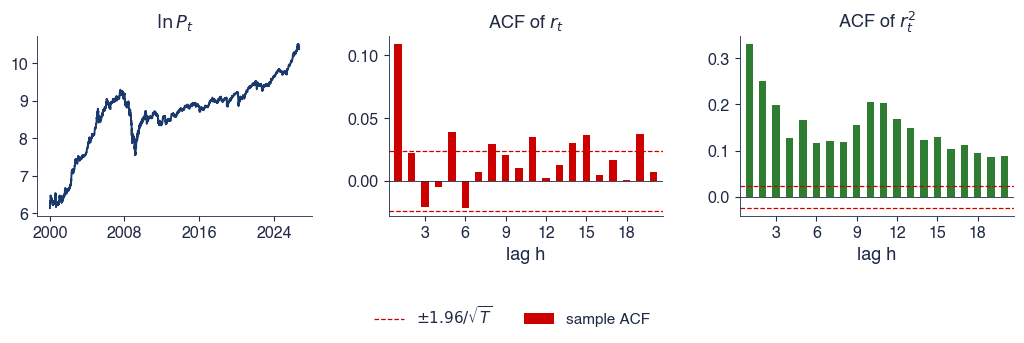

{'n': 6670,
 'first': '2000-01-06',
 'acf_p1': 0.9990530367885047,
 'acf_p10': 0.9907884300982461,
 'acf_p50': 0.9525434727933696,
 'r1': 0.1088283261694772,
 'r2': 0.02177176261404874,
 'r1sq': 0.011843604576850115,
 'band': np.float64(0.02399900047893674),
 'n_out': 7,
 'sq1': 0.33043644577381215,
 'lb_r': {'lb': 108.01843965612538,
  'lb_p': 1.3381539580012589e-18,
  'bp': 107.94946905891214,
  'bp_p': 1.3816390446114093e-18},
 'lb_r2': {'lb': 2439.975217306587,
  'lb_p': 0.0,
  'bp': 2437.741181597664,
  'bp_p': 0.0},
 'mean': 0.06393125538818989,
 'sd': 1.3986385699937032}

In [13]:
# Solution
b1 = b1_returns('bet', fname='ch1_sem_b1', save=False)
b1

**Interpretation of the result.** The level is random-walk-like (ACF close to 1 at lag 50). Returns have a small positive first-order autocorrelation: significant, but it explains about 1% of the variance. The squares are strongly autocorrelated: today's risk can be forecast from yesterday's move.

## B2 [Proposed]: the S&P 500 and EUR/RON

**Question.** Do the S&P 500 and the EUR/RON rate behave like the BET? Model: B1.

1. Repeat the three steps of B1 for both series (`b1_returns('sp500')`, `b1_returns('eurron', start=None)`).
2. Compare the sign and the size of $\hat\rho(1)$ of the returns across BET, S&P 500 and EUR/RON.
3. Compare $Q^*(10)$ of the squared returns across the three series.
4. Interpretation: which of the three return series is closest to white noise?

**Report:** one table (three series, six numbers each) and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: Romanian real GDP

**Question.** Which transformation makes Romanian quarterly GDP closest to stationary?

1. Compute $\ln Y_t$, $100\,\Delta\ln Y_t$ and $100\,\Delta_4\ln Y_t$.
2. Draw the three series and their ACF up to lag 12.
3. Report $\hat\rho(1)$, $\hat\rho(4)$ and $Q^*(8)$ for each.
4. Interpretation: why is $\hat\rho(4)$ of the quarterly growth rate close to 1?

**Report:** a table of nine numbers, the chart and two sentences.

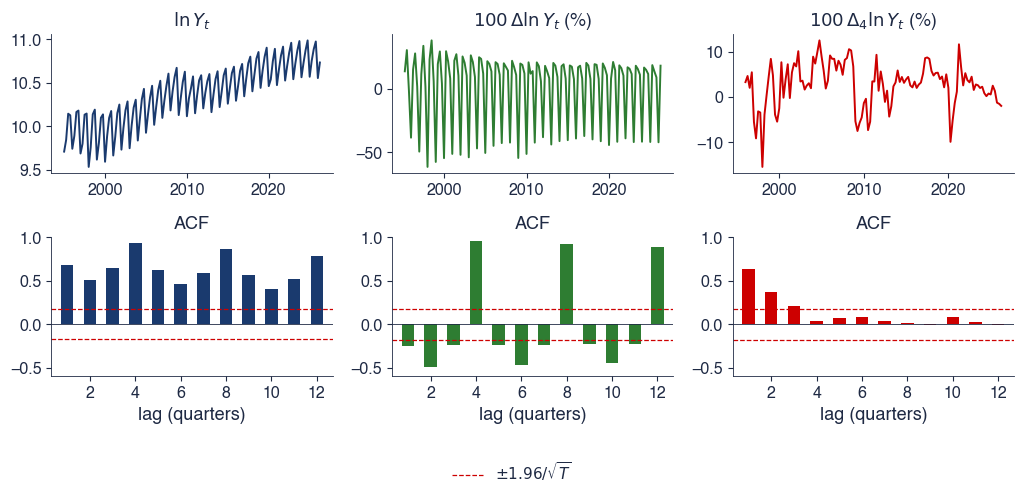

,rho1,rho4,Q*(8)
lev,0.68,0.94,494.98
d1,-0.24,0.96,329.64
d4,0.63,0.03,74.16


In [15]:
# Solution
b3 = b3_gdp(save=False)
pd.DataFrame({k: {'rho1': b3[k]['r1'], 'rho4': b3[k]['r4'], 'Q*(8)': b3[k]['lb8']['lb']} for k in ['lev', 'd1', 'd4']}).T.round(2)

**Interpretation of the result.** The quarterly rate of unadjusted GDP repeats the seasonal swing every year ($\hat\rho(4) \approx 1$). The annual rate removes the season; its ACF dies out after 2–3 quarters, but it reacts late to turning points and consecutive values overlap.

## B4 [Proposed]: Romanian inflation

**Question.** Is monthly Romanian inflation since 2005 white noise around its mean? Model: B3.

1. Compute the monthly inflation $100\,\Delta\ln P_t$ and the 12-month inflation $100\,\Delta_{12}\ln P_t$ from `ro_hicp()`.
2. Draw the ACF of both up to lag 36 and report $\hat\rho(1)$, $\hat\rho(12)$ and $\hat\rho(24)$.
3. Compute Ljung–Box $Q^*(12)$ for the monthly inflation.
4. Interpretation: what does the ACF of the monthly inflation say about how fast an inflation shock fades?

**Report:** six ACF values, one statistic with its p-value, the chart and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: has Romanian inflation become more persistent?

**Question.** Is monthly inflation more persistent after 2020 than in 2005–2019? Models: B1, B4.

1. Compute $\hat\rho(1)$ and $Q^*(12)$ in each subperiod, with the band of each.
2. Draw $\hat\rho(1)$ on rolling windows of 60 months.
3. List the events of 2020–2024 that could change the persistence.
4. Interpretation: why is the difference of two sample autocorrelations hard to judge with 80 observations?

**Report:** a table, the chart and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant interpreted the S&P 500 daily data since 2000. It answered:

- (a) the ACF of the log price at lag 1 is close to 1, so the log price is a stationary process with a very long memory;
- (b) the return autocorrelation at lag 1 is outside the band, so a trader can forecast most of tomorrow's return;
- (c) Ljung–Box Q(10) of the squared returns is very large, so the returns themselves are autocorrelated;
- (d) a weakly stationary process is always strictly stationary, since its mean and variance are constant;
- (e) differencing a series that is already stationary does no harm: white noise stays white noise;
- (f) a random walk has $\mathrm{Var}(X_t) = t\sigma^2$, so it is not stationary.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
